In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from trianglechain import TriangleChain
from sbi.diagnostics.misspecification import calc_misspecification_mmd

from msfm.utils import files, observation, cross_statistics, power_spectra

from deep_lss.utils import configuration

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor import architecture
from msi.utils import preprocessing, plotting

2026-01-29 05:44:28.353061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# load data

### v14

In [3]:
base_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended"
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
wl_dir = os.path.join(base_dir, "lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default")
wl_steps = 400_000

# classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
gc_dir = os.path.join(base_dir, "clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default")
gc_steps = 240_000

# Cross-probe posterior predictive distribution
lensing -> clustering
$$s_{gc}^{rep} \sim p(s_{gc} | s_{wl}^{obs}) = \int d\theta p(s_{gc} | \theta, s_{wl}^{obs}) p(\theta | s_{wl}^{obs})$$
clustering -> lensing
$$s_{wl}^{rep} \sim p(s_{wl} | s_{gc}^{obs}) = \int d\theta p(s_{wl} | \theta, s_{gc}^{obs}) p(\theta | s_{gc}^{obs})$$

In [4]:
def prepare_data(model_dir, model_steps, mock_label):
    _, s_grid, theta_grid, file_dict = preprocessing.get_reshaped_network_preds(
        model_dir,
        n_steps=model_steps,
        with_fidu=False,
    )
    s_obs = file_dict[f"mocks/pred/{mock_label}"]
    theta_post = np.load(os.path.join(model_dir, f"{model_steps}_steps_likelihood_sigmoid/likelihood_flow/chain_{mock_label}.npy"))

    return s_grid, s_obs, theta_grid, theta_post


def marginal_plot(s_obs, s_rep, s_prior, in_probe, plot_type):
    if in_probe == "lensing":
        prior_label = r"$p(s_{gc})$"
        post_label = r"$p(s_{gc}|s_{wl}^{obs})$"
        obs_label = r"$s_{wl}^{obs}$"
    elif in_probe == "clustering":
        prior_label = r"$p(s_{wl})$"
        post_label = r"$p(s_{wl}|s_{gc}^{obs})$"
        obs_label = r"$s_{gc}^{obs}$"

    tri = TriangleChain(
        show_legend=True,
        legend_fontsize=60,
    )

    if plot_type == "contour":
        tri.contour_cl(s_prior, color="tab:blue", label=prior_label)
        tri.contour_cl(s_rep, color="tab:orange", label=post_label)
    elif plot_type == "scatter":
        scatter_kwargs = {"s": 10, "marker": "o"}
        i_rand = rng.integers(0, s_prior.shape[0], n_plot)

        tri.scatter(s_prior[i_rand], color="tab:blue", scatter_kwargs=scatter_kwargs, label=prior_label)
        tri.scatter(s_rep[i_rand], color="tab:orange", scatter_kwargs=scatter_kwargs, label=post_label)

    tri.scatter(np.atleast_2d(s_obs), scatter_kwargs={"s": 500, "marker": "*"}, color="k", scatter_vline_1D=True, plot_histograms_1D=False, label=prior_label);


def mmd_test(s_obs, s_rep):
    s_obs = np.atleast_2d(s_obs)
    
    p_val, (mmds_baseline, mmd) = calc_misspecification_mmd(
        x_obs=torch.from_numpy(s_obs).float(), 
        x=torch.from_numpy(s_rep).float(),
    )
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    ax.hist(mmds_baseline.numpy(), bins=100, alpha=0.5, label="baseline")
    ax.axvline(mmd.item(), color="k", label=r"MMD($s^{rep}$, $s^{obs}$)")
    
    ax.set(xlabel="MMD", ylabel="Count", title=f"p = {p_val:.4f}")
    ax.legend()


def log_prob_test(s_obs, s_rep, context, flow, in_probe):
    log_prob_rep = flow.log_likelihood(
        s_rep,
        context,
        return_numpy=True
    )
    log_prob_obs = flow.log_likelihood(
        np.repeat(np.atleast_2d(s_obs), context.shape[0], axis=0),
        context,
        return_numpy=True
    )
    p_val = np.mean(log_prob_obs < log_prob_rep)

    if in_probe == "lensing":
        rep_label = r"$\log p(s_{gc}^{rep} | \theta^\star, s_{wl}^{obs})$"
        obs_label = r"$\log p(s_{gc}^{obs} | \theta^\star, s_{wl}^{obs})$"
    
    elif in_probe == "clustering":
        rep_label = r"$\log p(s_{wl}^{rep} | \theta^\star, s_{gc}^{obs})$"
        obs_label = r"$\log p(s_{wl}^{obs} | \theta^\star, s_{gc}^{obs})$"

    fig, ax = plt.subplots(figsize=(8,6))
    
    ax.hist(log_prob_rep, bins=100, label=rep_label, alpha=0.5)
    ax.hist(log_prob_obs, bins=100, label=obs_label, alpha=0.5)

    ax.set(xlabel="log prob", ylabel="Count", title=f"p = {p_val:.4f}")
    ax.legend()


def sample_cross_probe_ppd(
    in_probe, 
    mock_label,
    train_flow=False, 
    plot_type="contour", 
    n_star=100_000,
    n_plot=1_000,
    np_seed=11
):
    rng = np.random.default_rng(np_seed)
    
    s_wl_grid, s_wl_obs, theta_wl_grid, theta_wl_post = prepare_data(wl_dir, wl_steps, mock_label)
    s_gc_grid, s_gc_obs, theta_gc_grid, theta_gc_post = prepare_data(gc_dir, gc_steps, mock_label)

    assert np.all(theta_wl_grid[:,:3] == theta_gc_grid[:,:3])

    print("\n")
    if in_probe == "lensing":
        out_probe = "clustering"
        s_prior = s_gc_grid
        s_obs_ref = s_gc_obs
        
        print(f"flow = p(s_gc | theta_wl, s_wl)")
        flow_dir = gc_dir
        features_grid = s_gc_grid
        context_grid = np.concatenate([theta_wl_grid, s_wl_grid], axis=-1)

        print(f"post = p(theta_wl | s_wl)")
        theta_post = theta_wl_post
        s_obs = s_wl_obs
        
    if in_probe == "clustering":
        out_probe = "lensing"
        s_prior = s_wl_grid
        s_obs_ref = s_wl_obs
        
        print(f"flow = p(s_wl | theta_gc, s_gc)")
        flow_dir = wl_dir
        features_grid = s_wl_grid
        context_grid = np.concatenate([theta_gc_grid, s_gc_grid], axis=-1)
        
        print(f"post = p(theta_gc | s_gc)")
        theta_post = theta_gc_post
        s_obs = s_gc_obs
        
    print(f"Conditioning on {in_probe} and sampling in {out_probe} summary space")

    flow = LikelihoodFlow(
        params=[],
        conf=conf, 
        embedding_net=architecture.get_context_embedding_net(context_grid.shape[-1]),
        base_dist=architecture.get_normal_dist(features_grid.shape[-1]),
        transform=architecture.get_sigmoids_transform(features_grid.shape[-1]),
        out_dir=flow_dir,
        label=f"cross_tests",
        load_existing=not train_flow,
    )

    if train_flow:
        flow.fit(
            x=features_grid,
            theta=context_grid,
            batch_size=10_000,
            scheduler_type="cosine",
            save_model=True,
        )

    # subsample the posterior
    i_star = rng.integers(0, theta_post.shape[0], n_star)
    theta_star = theta_post[i_star]
    
    # sample the flow
    s_obs_star = np.repeat(s_obs[np.newaxis], n_star, axis=0)
    context_star = np.concatenate([theta_star, s_obs_star], axis=-1)
    s_rep = flow.sample_likelihood(
        context_star,
        n_samples=1,
        batch_size=context_star.shape[0]//10,
    )
    s_rep = np.squeeze(s_rep)
    
    marginal_plot(s_obs_ref, s_rep, s_prior, in_probe, plot_type)
    mmd_test(s_obs_ref, s_rep)
    log_prob_test(s_obs_ref, s_rep, context_star, flow, in_probe)

    return flow, s_obs_ref, s_rep, s_prior


26-01-29 05:45:21 input_output INF   Loading predictions from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_400000.h5 
26-01-29 05:45:21 input_output INF   Array shapes: 
26-01-29 05:45:21 input_output INF   fiducial/vali/pred = (40000, 12) 
26-01-29 05:45:21 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-29 05:45:21 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-29 05:45:21 input_output INF   grid/pred          = (2500, 80, 12) 
26-01-29 05:45:21 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-01-29 05:45:21 input_output INF   grid/i_example     = (2500, 80) 
26-01-29 05:45:21 input_output INF   grid/i_noise       = (2500, 80) 
26-01-29 05:45:21 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-29 05:45:21 preprocessin INF   Shapes after concatenation and selection: 
26-01-29 05:45:21 preprocessin INF   grid_preds  = (200000, 12) 
26-01-29 05:45:21 preprocess

/global/u2/a/athomsen/multiprobe-simulation-inference/msi/flow_conductor/likelihood_flow.py:501: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.loa

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

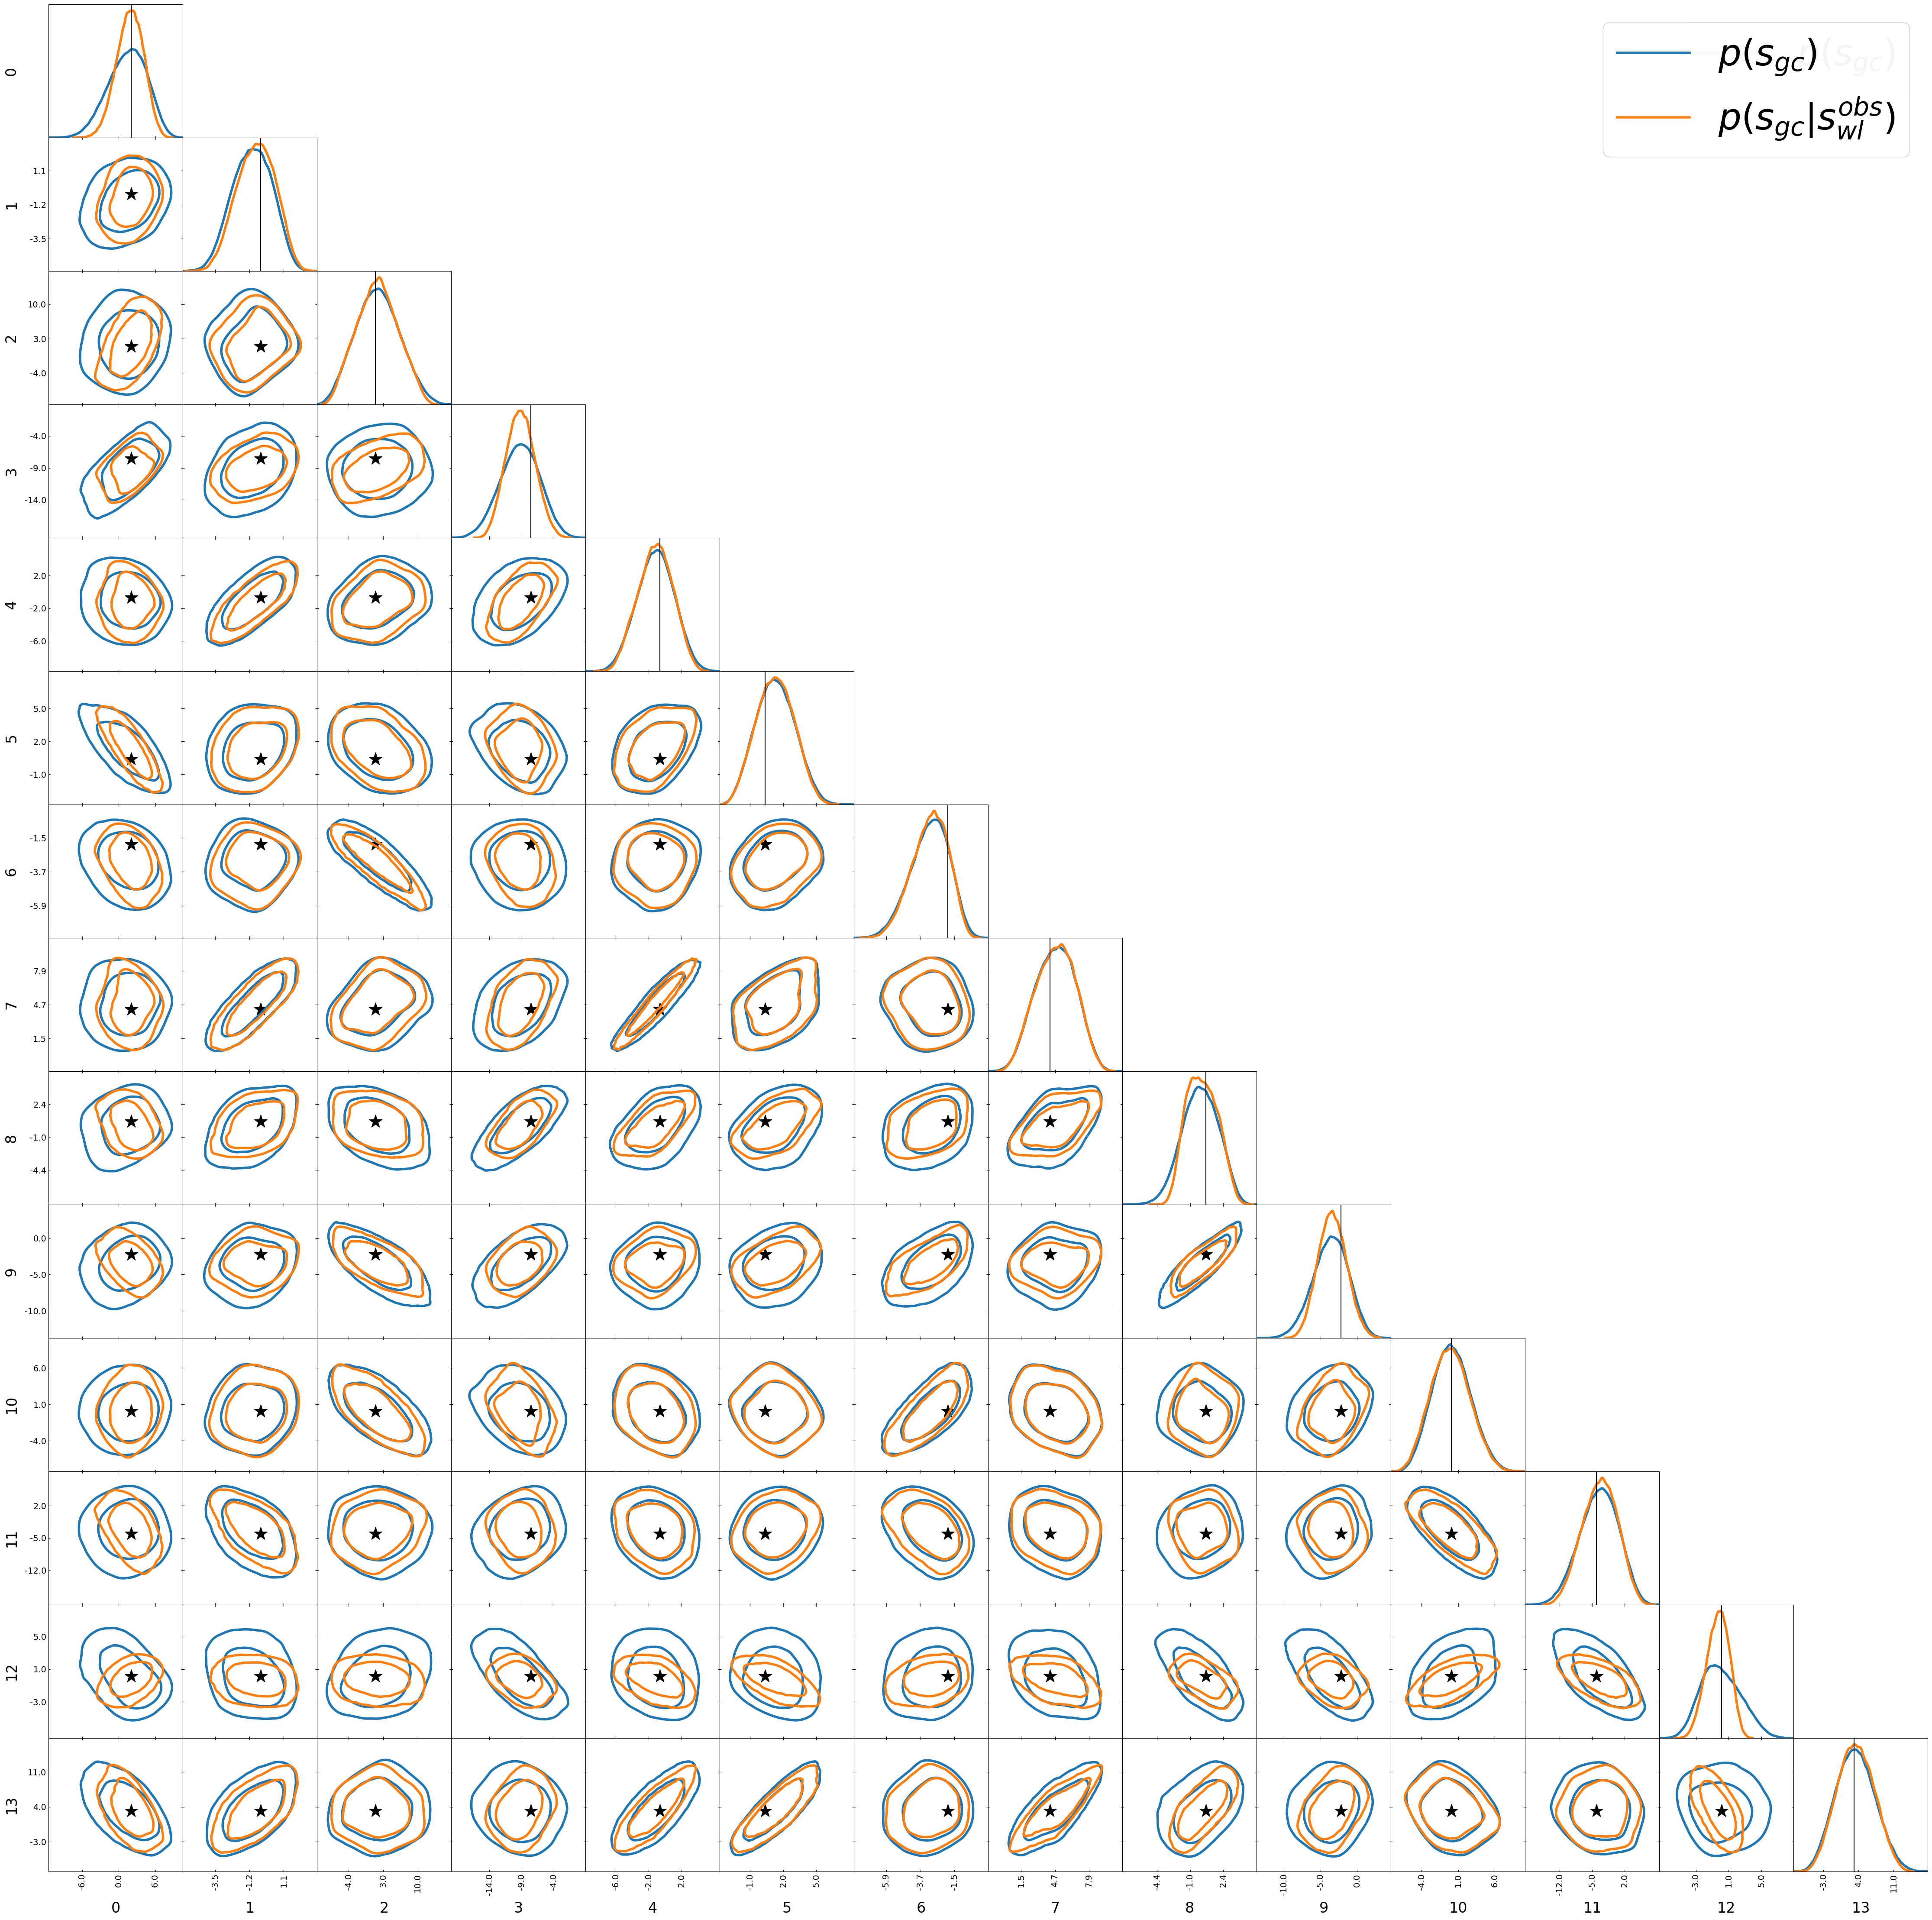

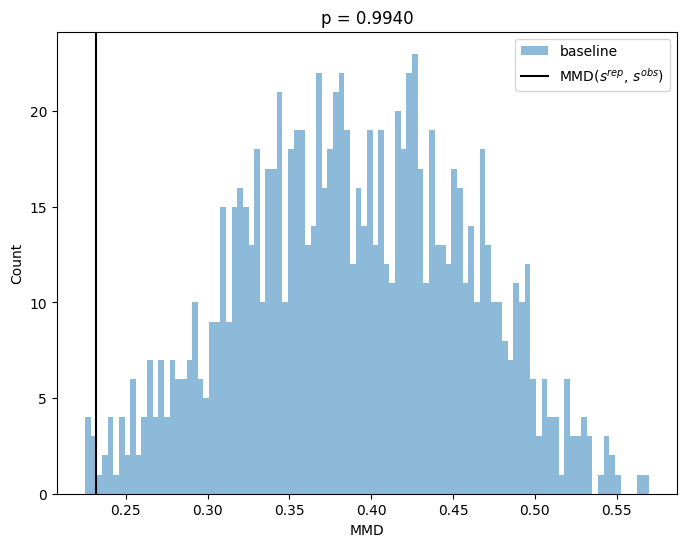

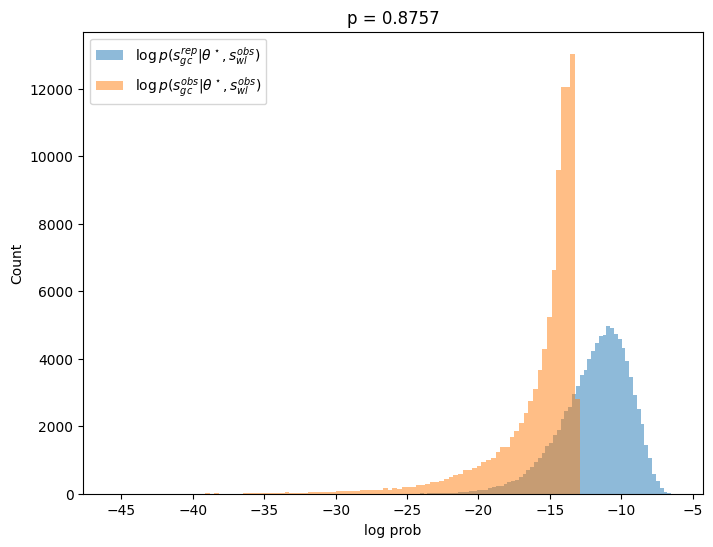

In [5]:
flow, s_obs_ref, s_rep, s_prior = sample_cross_probe_ppd(
    # in_probe="clustering",
    in_probe="lensing",
    # mock_label="Buzzard_0",
    # mock_label="Buzzard_3",
    mock_label="Buzzard_7",
    # mock_label="bench_fidu_mean",
    train_flow=False, 
)